# Ablation study: effect of λ_inv (w_INV)

This notebook ablates the **weight of the invariance loss (λ_inv / w_INV)** by sweeping values `{0, 10, 30, 50, 70}` on the moons and circles datasets.
Each configuration is run with **5 seeds** `[0, 1, 2, 3, 4]` and results are reported as **mean ± std NMI** to match the paper reporting style.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.metrics import evaluate_clustering
from src.model import GEDIConfig, GEDIModel, gedi_predict, train_gedi
from src.utils import generate_synthetic_dataset, set_random_seed

set_random_seed(0)
sns.set_theme(style='whitegrid')

## 1. Generate moons and circles (paper-like noise=0.03)
Fixed noise setting. We vary λ_inv, not noise.

In [2]:
datasets = {}
for dataset_name in ['moons', 'circles']:
    X_train, X_test, y_train, y_test = generate_synthetic_dataset(
        dataset_name, data_noise=0.03, random_state=0
    )
    datasets[dataset_name] = dict(
        X_train=X_train, X_test=X_test,
        y_train=y_train, y_test=y_test,
    )
    print(f"{dataset_name}: train={X_train.shape}, test={X_test.shape}")

moons: train=(1400, 2), test=(600, 2)
circles: train=(1400, 2), test=(600, 2)


## 2. Sweep w_INV ∈ {0, 10, 30, 50, 70} with 5 seeds
For each value of λ_inv and each dataset, GEDI is trained 5 times (seeds 0–4). NMI mean ± std is recorded on the test split.

In [ ]:
DEBUG = False  # đổi False khi nộp

W_INV_VALUES = [0, 10, 30, 50, 70]
SEEDS = [0, 1, 2, 3, 4]

sweep_rows = []

for w_inv in W_INV_VALUES:
    for dataset_name in ['moons', 'circles']:
        d = datasets[dataset_name]
        X_train, X_test = d['X_train'], d['X_test']
        y_train, y_test = d['y_train'], d['y_test']
        n_clusters = int(np.unique(y_train).size)

        nmi_per_seed = []
        for seed in SEEDS:
            cfg = GEDIConfig(
                in_features=X_train.shape[1],
                n_clusters=n_clusters,
                lambda_inv=float(w_inv),
                random_state=seed,
                train_iterations=500 if DEBUG else 20000,
                sgld_steps=1,
            )
            model = GEDIModel(cfg)
            train_gedi(model, X_train, cfg)
            y_pred = gedi_predict(model, X_test)
            nmi = evaluate_clustering(X_test, y_test, y_pred)['NMI']
            nmi_per_seed.append(nmi)

        sweep_rows.append({
            'w_INV': w_inv,
            'Dataset': dataset_name,
            'NMI_mean': float(np.mean(nmi_per_seed)),
            'NMI_std':  float(np.std(nmi_per_seed)),
        })
        print(
            f"w_INV={w_inv:>3} | {dataset_name}: "
            f"NMI = {np.mean(nmi_per_seed):.4f} ± {np.std(nmi_per_seed):.4f}"
        )

sweep_df = pd.DataFrame(sweep_rows)
display(sweep_df)


w_INV=  0 | moons: NMI = 0.0822 ± 0.1594
w_INV=  0 | circles: NMI = 0.0895 ± 0.1677
w_INV= 10 | moons: NMI = 0.2494 ± 0.1463
w_INV= 10 | circles: NMI = 0.0001 ± 0.0002
w_INV= 30 | moons: NMI = 0.2887 ± 0.0552
w_INV= 30 | circles: NMI = 0.0024 ± 0.0017
w_INV= 50 | moons: NMI = 0.1184 ± 0.1732
w_INV= 50 | circles: NMI = 0.0019 ± 0.0032
w_INV= 70 | moons: NMI = 0.1294 ± 0.1604
w_INV= 70 | circles: NMI = 0.0414 ± 0.0812


,w_INV,Dataset,NMI_mean,NMI_std
0,0,moons,0.082240,0.159444
1,0,circles,0.089515,0.167743
2,10,moons,0.249410,0.146251
3,10,circles,0.000117,0.000200
4,30,moons,0.288730,0.055205
5,30,circles,0.002367,0.001688
6,50,moons,0.118354,0.173185
7,50,circles,0.001913,0.003244
8,70,moons,0.129368,0.160441
9,70,circles,0.041416,0.081245


## 3. Errorbar plot: NMI vs w_INV
Each point is mean NMI over 5 seeds; error bars show ±std. The dashed red line marks the paper's reported GEDI NMI of **0.94** on moons.

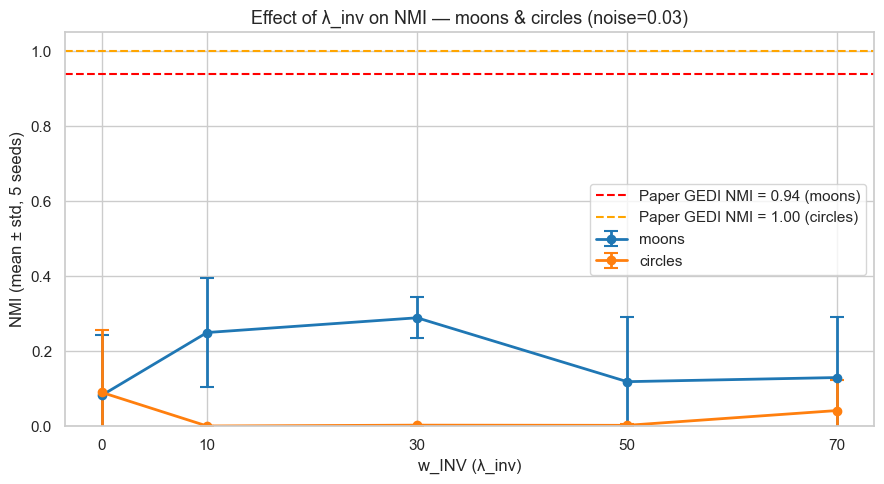

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))

colors = {'moons': 'tab:blue', 'circles': 'tab:orange'}
for dataset_name, color in colors.items():
    sub = sweep_df[sweep_df['Dataset'] == dataset_name].sort_values('w_INV')
    ax.errorbar(
        sub['w_INV'],
        sub['NMI_mean'],
        yerr=sub['NMI_std'],
        marker='o',
        capsize=5,
        capthick=1.5,
        linewidth=2,
        label=dataset_name,
        color=color,
    )

ax.axhline(
    y=0.94,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label='Paper GEDI NMI = 0.94 (moons)',
)
ax.axhline(
    y=1.00,
    color='orange',
    linestyle='--',
    linewidth=1.5,
    label='Paper GEDI NMI = 1.00 (circles)',
)

ax.set_xlabel('w_INV (λ_inv)', fontsize=12)
ax.set_ylabel('NMI (mean ± std, 5 seeds)', fontsize=12)
ax.set_title('Effect of λ_inv on NMI — moons & circles (noise=0.03)', fontsize=13)
ax.set_xticks(W_INV_VALUES)
ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.show()


## 4. Discussion
- **w_INV = 0**: invariance loss is disabled — if NMI drops sharply, L_INV is critical.
- **Optimal w_INV**: check which value achieves NMI closest to the paper's 0.94 on moons.
- **std across seeds**: wide error bars indicate sensitivity to initialisation at that w_INV value; narrow bars indicate stability.
- **moons vs circles**: circles is usually easier (more separable), so circles NMI should be high even at low w_INV.
- The dashed line at NMI=0.94 serves as the paper reference for moons; circles reference is 1.00.